In [1]:
import pypsa

In [2]:
import pandas as pd

In [10]:

n = pypsa.Network(r"solved_networks_core\solved\baseline\bat1x_gas24_coal14.2_co2_93_cy2009_dur1x.nc")

# ------------------------------------------------------------

DE = "DE00"

print("\n=== NETWORK ===")
print("snapshots:", len(n.snapshots))
print("first snapshot:", n.snapshots[0])
print("last snapshot:", n.snapshots[-1])



INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks



=== NETWORK ===
snapshots: 8760
first snapshot: 2030-01-01 00:00:00
last snapshot: 2030-12-31 23:00:00


In [11]:
# 1. German generators
de_gen = n.generators[n.generators.bus == DE].copy()

gen_cols = [
    c for c in [
        "carrier",
        "p_nom",
        "marginal_cost",
        "efficiency",
        "p_min_pu",
        "p_max_pu",
    ]
    if c in de_gen.columns
]

print("\n=== DE00 GENERATORS ===")
print(
    de_gen[gen_cols]
    .sort_values(["carrier", "p_nom"], ascending=[True, False])
    .to_string()
)

print("\n=== DE00 GENERATION CAPACITY BY CARRIER [MW] ===")
print(
    de_gen.groupby("carrier")["p_nom"]
    .sum()
    .sort_values(ascending=False)
    .to_string()
)


=== DE00 GENERATORS ===
                                                         carrier         p_nom  marginal_cost  efficiency  p_min_pu  p_max_pu
name                                                                                                                         
DE00-dsr-Price_Band_14_3                                     dsr  1.000000e+04      87.100000         1.0       0.0       1.0
DE00-dsr-Price_Band_15_3                                     dsr  8.800000e+03      43.600000         1.0       0.0       1.0
DE00-dsr-Price_Band_2                                        dsr  1.838700e+03       5.000000         1.0       0.0       1.0
DE00-dsr-Price_Band_9                                        dsr  1.307200e+03      10.000000         1.0       0.0       1.0
DE00-dsr-Price_Band_13                                       dsr  4.717000e+02     200.000000         1.0       0.0       1.0
DE00-dsr-Price_Band_10                                       dsr  3.042000e+02      20.000000

C:\Users\michaela.lelova\AppData\Local\Temp\ipykernel_3892\3416653079.py:4: DtypeWarning: Columns (0: symbol_name, 1: genscape/power/supply/de.cap_inst.bl.bio.d.c, 2: genscape/power/supply/de.cap_inst.bl.btry.d.c, 3: genscape/power/supply/de.cap_inst.bl.ccgt.d.c, 4: genscape/power/supply/de.cap_inst.bl.coal.d.c, 5: genscape/power/supply/de.cap_inst.bl.engine.d.c, 6: genscape/power/supply/de.cap_inst.bl.gas_boiler.d.c, 7: genscape/power/supply/de.cap_inst.bl.geo.d.c, 8: genscape/power/supply/de.cap_inst.bl.gt.d.c, 9: genscape/power/supply/de.cap_inst.bl.hydro_ps.d.c, 10: genscape/power/supply/de.cap_inst.bl.hydro_res.d.c, 11: genscape/power/supply/de.cap_inst.bl.hydro_ror.d.c, 12: genscape/power/supply/de.cap_inst.bl.lig.d.c, 13: genscape/power/supply/de.cap_inst.bl.nuc.d.c, 14: genscape/power/supply/de.cap_inst.bl.oil.d.c, 15: genscape/power/supply/de.cap_inst.bl.spv.d.c, 16: genscape/power/supply/de.cap_inst.bl.waste.d.c, 17: genscape/power/supply/de.cap_inst.bl.wnd.d.c, 18: genscape/

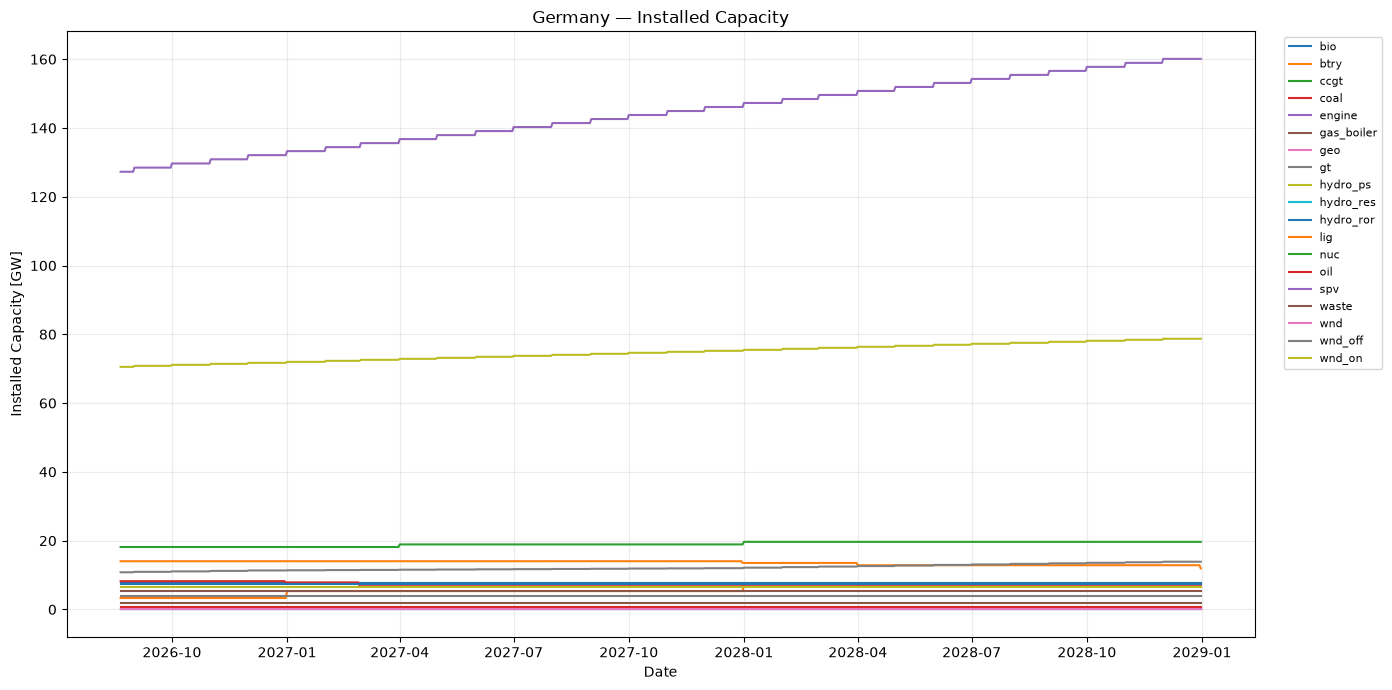

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("company_data/inst_cap.csv")

# First column contains metadata labels followed by timestamps
index_col = df.columns[0]

# Identify rows containing actual time-series observations
parsed_dates = pd.to_datetime(df[index_col], errors="coerce")
mask = parsed_dates.notna()

capacity = (
    df.loc[mask]
      .drop(columns=index_col)
      .apply(pd.to_numeric, errors="coerce")
)

capacity.index = parsed_dates[mask]
capacity = capacity.dropna(axis=1, how="all")

# Shorten names automatically
# e.g. genscape/power/supply/de.cap_inst.bl.ccgt.d.c -> ccgt
capacity.columns = [
    col.split(".")[-3]
    for col in capacity.columns
]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for column in capacity.columns:
    ax.plot(
        capacity.index,
        capacity[column],
        label=column,
        linewidth=1.5,
    )

ax.set_title("Germany — Installed Capacity")
ax.set_xlabel("Date")
ax.set_ylabel("Installed Capacity [GW]")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
)

ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [12]:
de_gen = n.generators[n.generators.bus == "DE00"].copy()

model = pd.Series({
    "ccgt": de_gen.loc[
        de_gen.index.str.contains("gas-ccgt"), "p_nom"
    ].sum() / 1000,

    "gt": de_gen.loc[
        de_gen.index.str.contains("gas-ocgt"), "p_nom"
    ].sum() / 1000,

    "gas_conv": de_gen.loc[
        de_gen.index.str.contains("gas-conv"), "p_nom"
    ].sum() / 1000,

    "oil": de_gen.loc[
        de_gen.index.str.contains("oil"), "p_nom"
    ].sum() / 1000,

    "hydro_ror": de_gen.loc[
        de_gen.carrier == "hydro-ror", "p_nom"
    ].sum() / 1000,

    "wnd_on": de_gen.loc[
        de_gen.carrier == "onwind", "p_nom"
    ].sum() / 1000,

    "wnd_off": de_gen.loc[
        de_gen.carrier == "offwind", "p_nom"
    ].sum() / 1000,

    "spv": de_gen.loc[
        de_gen.carrier.isin(["solar-pv-utility", "solar-pv-rooftop"]),
        "p_nom"
    ].sum() / 1000,

    "other_res": de_gen.loc[
        de_gen.carrier == "other-res", "p_nom"
    ].sum() / 1000,
})

model

ccgt          22.245865
gt             2.399106
gas_conv       8.334787
oil            1.585330
hydro_ror      3.933900
wnd_on       115.000700
wnd_off       30.521300
spv          215.002000
other_res     13.067586
dtype: float64

In [9]:
# 2. German storage
de_storage = n.storage_units[n.storage_units.bus == DE].copy()

storage_cols = [
    c for c in [
        "carrier",
        "p_nom",
        "max_hours",
        "efficiency_store",
        "efficiency_dispatch",
        "cyclic_state_of_charge",
    ]
    if c in de_storage.columns
]

print("\n=== DE00 STORAGE ===")
print(de_storage[storage_cols].to_string())

if len(de_storage):
    tmp = de_storage.copy()
    tmp["energy_capacity_MWh"] = tmp["p_nom"] * tmp["max_hours"]

    print("\n=== DE00 STORAGE POWER / ENERGY ===")
    print(
        tmp[
            ["carrier", "p_nom", "max_hours", "energy_capacity_MWh"]
        ].to_string()
    )


=== DE00 STORAGE ===
                              carrier    p_nom   max_hours  efficiency_store  efficiency_dispatch  cyclic_state_of_charge
name                                                                                                                     
DE00-battery                  battery  3200.40    2.000000              0.96                 0.96                    True
DE00-hydro-phs              hydro-phs  2144.10  204.355674              0.90                 0.90                    True
DE00-hydro-phs-pure    hydro-phs-pure  7009.84   39.394591              0.90                 0.90                    True
DE00-hydro-reservoir  hydro-reservoir   819.00  289.642288              1.00                 0.90                    True

=== DE00 STORAGE POWER / ENERGY ===
                              carrier    p_nom   max_hours  energy_capacity_MWh
name                                                                           
DE00-battery                  battery  3200.40   

In [10]:
# 3. German demand
de_load_names = n.loads.index[n.loads.bus == DE]
de_demand = n.loads_t.p_set[de_load_names].sum(axis=1)

print("\n=== DE00 DEMAND ===")
print("peak MW:", de_demand.max())
print("mean MW:", de_demand.mean())
print("annual TWh:", de_demand.sum() / 1e6)

# 4. German interconnectors
de_links = n.links[
    (n.links.bus0 == DE) | (n.links.bus1 == DE)
].copy()

link_cols = [
    c for c in ["bus0", "bus1", "p_nom", "p_min_pu", "p_max_pu", "efficiency"]
    if c in de_links.columns
]

print("\n=== DE00 INTERCONNECTORS ===")
print(de_links[link_cols].to_string())

print("\n=== TOTAL DE00 BORDER LINK CAPACITY [MW] ===")
print(de_links["p_nom"].sum())


=== DE00 DEMAND ===
peak MW: 152345.37199662047
mean MW: 81725.35798078073
annual TWh: 715.914135911639

=== DE00 INTERCONNECTORS ===
              bus0  bus1   p_nom  p_min_pu  p_max_pu  efficiency
name                                                            
AT00-DE00-DC  AT00  DE00  7500.0       0.0       1.0        0.97
BE00-DE00-DC  BE00  DE00  1000.0       0.0       1.0        0.97
CH00-DE00-DC  CH00  DE00  4200.0       0.0       1.0        0.97
CZ00-DE00-DC  CZ00  DE00  2600.0       0.0       1.0        0.97
DE00-AT00-DC  DE00  AT00  7500.0       0.0       1.0        0.97
DE00-BE00-DC  DE00  BE00  1000.0       0.0       1.0        0.97
DE00-CH00-DC  DE00  CH00  4400.0       0.0       1.0        0.97
DE00-CZ00-DC  DE00  CZ00  2500.0       0.0       1.0        0.97
DE00-DKE1-DC  DE00  DKE1   600.0       0.0       1.0        0.97
DE00-DKW1-DC  DE00  DKW1  3500.0       0.0       1.0        0.97
DE00-FR00-DC  DE00  FR00  4800.0       0.0       1.0        0.97
DE00-GB00-DC  DE00  

| Assumption                    | Effective model value |
| ----------------------------- | --------------------: |
| Demand                        |    **715.9 TWh/year** |
| Mean demand                   |           **81.7 GW** |
| Peak demand                   |          **152.3 GW** |
| Solar rooftop                 |          **118.0 GW** |
| Solar utility                 |           **97.0 GW** |
| Solar total                   |          **215.0 GW** |
| Onshore wind                  |          **115.0 GW** |
| Offshore wind                 |           **30.5 GW** |
| Gas                           |           **25.7 GW** |
| H₂ CCGT                       |           **8.83 GW** |
| Hydro run-of-river            |           **3.93 GW** |
| Other RES                     |           **13.1 GW** |
| Other thermal                 |           **7.28 GW** |
| Oil                           |           **1.59 GW** |
| DSR                           |           **23.8 GW** |
| Battery power                 |          **3.200 GW** |
| Battery energy                |         **6.401 GWh** |
| Battery duration              |             **2.0 h** |
| Battery charge efficiency     |               **96%** |
| Battery discharge efficiency  |               **96%** |
| Battery round-trip efficiency |            **≈92.2%** |
| Slack marginal cost           |        **€3,000/MWh** |


22.68 eur/mwh set gas price in the scenario <br>
marginal costs for gas plants: ccgt = 79.85 | ocgt = 111.43 <br>

fuel price + efficiency + CO₂ price + emission factor + VOM → marginal cost

In [ ]:

from scenarios.load_network_data import load_network_data


data = load_network_data(
    data_dir="data/open-tyndp",
    tyndp_dir="data/tyndp2024",
    climate_year=2009,
    gas_price=22.68,
    co2_price=113.4,
)


In [13]:

tech = data["technologies"]

cost_cols = [
    "index_carrier",
    "pypsa_carrier",
    "fuel_type",
    "efficiency",
    "vom_eur_mwh",
    "fuel_price_eur_mwh",
    "co2_tco2_mwh",
    "marginal_cost_eur_mwh",
]
gas = tech[
    tech["fuel_type"].astype(str).str.lower() == "gas"
]

print(gas[cost_cols].to_string(index=False))

                                        index_carrier pypsa_carrier fuel_type  efficiency  vom_eur_mwh  fuel_price_eur_mwh  co2_tco2_mwh  marginal_cost_eur_mwh
           chp-gas-ccgt-ccs-other-65.2870588235294eur other-thermal       gas        0.58       4.4445               22.68      0.020520              47.559962
          chp-gas-ccgt-new-other-77.04000000000002eur other-thermal       gas        0.58       4.4445               22.68      0.185652              79.846115
                 chp-gas-ccgt-old-1-industrial-200eur other-thermal       gas        0.58       4.4445               22.68      0.185652              79.846115
                 chp-gas-ccgt-old-1-industrial-520eur other-thermal       gas        0.58       4.4445               22.68      0.185652              79.846115
                        chp-gas-ccgt-old-1-other-0eur other-thermal       gas        0.58       4.4445               22.68      0.185652              79.846115
        chp-gas-ccgt-old-1-other-509.999

comparing what relies on climate year

In [15]:
d09 = load_network_data(
    data_dir="data/open-tyndp",
    tyndp_dir="data/tyndp2024",
    climate_year=2009,
    gas_price=22.68,
    co2_price=113.4,
)

d12 = load_network_data(
    data_dir="data/open-tyndp",
    tyndp_dir="data/tyndp2024",
    climate_year=2012,
    gas_price=22.68,
    co2_price=113.4,
)

Loading network data: data_dir=data\open-tyndp, tyndp_dir=data\tyndp2024
  climate_year=2009, gas_price=22.68, co2_price=113.4
[1/4] Loading fixed data...
[2/4] Loading PECD profiles (CY=2009)...
  Onshore: 62 buses, Offshore: 26 buses, Utility: 61 buses, Rooftop: 61 buses
[3/4] Loading demand (CY=2009)...
  63 buses
[4/4] Loading hydro inflows (CY=2009)...
  RoR: 43 buses, Reservoir: 43 buses, Pondage: 43 buses, PS Open: 43 buses
Data loading complete.
Loading network data: data_dir=data\open-tyndp, tyndp_dir=data\tyndp2024
  climate_year=2012, gas_price=22.68, co2_price=113.4
[1/4] Loading fixed data...
[2/4] Loading PECD profiles (CY=2012)...
  Onshore: 62 buses, Offshore: 26 buses, Utility: 61 buses, Rooftop: 61 buses
[3/4] Loading demand (CY=2012)...
  63 buses
[4/4] Loading hydro inflows (CY=2012)...
  RoR: 43 buses, Reservoir: 43 buses, Pondage: 43 buses, PS Open: 43 buses
Data loading complete.


In [17]:
print("=== CY2009 vs CY2012 ===")

for key in d09.keys():
    a = d09[key]
    b = d12[key]

    print(f"\n{key}")

    if hasattr(a, "shape"):
        print("  shape 2009:", a.shape)
        print("  shape 2012:", b.shape)
        print("  exactly equal:", a.equals(b))
    else:
        print("  2009:", a)
        print("  2012:", b)
        print("  exactly equal:", a == b)

=== CY2009 vs CY2012 ===

buses
  shape 2009: (55, 11)
  shape 2012: (55, 11)
  exactly equal: True

links
  shape 2009: (219, 10)
  shape 2012: (219, 10)
  exactly equal: True

capacities
  shape 2009: (2010, 10)
  shape 2012: (2010, 10)
  exactly equal: True

technologies
  shape 2009: (69, 15)
  shape 2012: (69, 15)
  exactly equal: True

offshore_cap
  shape 2009: (26,)
  shape 2012: (26,)
  exactly equal: True

offshore_cap_df
  shape 2009: (26, 3)
  shape 2012: (26, 3)
  exactly equal: True

nuclear_profiles
  shape 2009: (8760, 14)
  shape 2012: (8760, 14)
  exactly equal: True

other_res_pmax
  shape 2009: (8760, 45)
  shape 2012: (8760, 45)
  exactly equal: True

dsr_static
  shape 2009: (78, 8)
  shape 2012: (76, 8)
  exactly equal: False

dsr_ts
  shape 2009: (8760, 79)
  shape 2012: (8760, 79)
  exactly equal: True

climate_year
  2009: 2009
  2012: 2012
  exactly equal: False

wind_onshore
  shape 2009: (8760, 62)
  shape 2012: (8760, 62)
  exactly equal: False

wind_offsh

| Input                  | CY2009 vs CY2012 | Classification    |
| ---------------------- | ---------------- | ----------------- |
| Buses                  | identical        | scenario/static   |
| Links / NTC            | identical        | scenario/static   |
| Generation capacities  | identical        | scenario/static   |
| Technologies           | identical        | scenario/static   |
| Offshore capacity      | identical        | scenario/static   |
| Nuclear availability   | identical        | fixed profile     |
| Other RES availability | identical        | fixed profile     |
| Wind onshore           | **changes**      | climate/weather   |
| Wind offshore          | **changes**      | climate/weather   |
| Solar utility          | **changes**      | climate/weather   |
| Solar rooftop          | **changes**      | climate/weather   |
| Electricity demand     | **changes**      | climate/weather   |
| Run-of-river hydro     | **changes**      | climate/hydrology |
| Reservoir hydro        | **changes**      | climate/hydrology |
| Pondage hydro          | **changes**      | climate/hydrology |
| Open-loop PHS hydro    | **changes**      | climate/hydrology |
| DSR time series        | identical        | fixed profile     |
| DSR static             | **changes**      | investigate       |


In [18]:
a = d09["dsr_static"]
b = d12["dsr_static"]

print("=== DSR STATIC COLUMNS ===")
print(a.columns.tolist())

print("\n=== ROWS ONLY IN CY2009 ===")
print(
    a.loc[~a.index.isin(b.index)]
    .to_string()
)

print("\n=== ROWS ONLY IN CY2012 ===")
print(
    b.loc[~b.index.isin(a.index)]
    .to_string()
)

print("\n=== COMMON ROWS WITH DIFFERENT VALUES ===")
common = a.index.intersection(b.index)

diff_mask = (
    a.loc[common]
    .astype(str)
    .ne(b.loc[common].astype(str))
    .any(axis=1)
)

print(a.loc[common[diff_mask]].to_string())

if diff_mask.any():
    print("\n--- CY2012 values for those rows ---")
    print(b.loc[common[diff_mask]].to_string())

=== DSR STATIC COLUMNS ===
['node', 'price_band', 'Capacity', 'Units', 'Hours', 'Price', 'Climate year start', 'Climate year end']

=== ROWS ONLY IN CY2009 ===
    node       price_band  Capacity  Units  Hours  Price  Climate year start  Climate year end
24  DE00  Price Band 14_3   10000.0      1     24   87.1                2009              2009
27  DE00  Price Band 15_3    8800.0      1     24   43.6                2009              2009

=== ROWS ONLY IN CY2012 ===
Empty DataFrame
Columns: [node, price_band, Capacity, Units, Hours, Price, Climate year start, Climate year end]
Index: []

=== COMMON ROWS WITH DIFFERENT VALUES ===
Empty DataFrame
Columns: [node, price_band, Capacity, Units, Hours, Price, Climate year start, Climate year end]
Index: []
